In [12]:
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle
from xgboost import XGBClassifier


In [13]:
#load data and did hot encoding 
heart_data=pd.read_csv('heart.csv')
y=heart_data["HeartDisease"]
X=heart_data.drop(columns=["HeartDisease",])

variable=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
#do hot-encoding
X=pd.get_dummies(data=X,prefix=variable,columns=variable)
print(X.dtypes)

Age                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
Oldpeak              float64
Sex_F                   bool
Sex_M                   bool
ChestPainType_ASY       bool
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_LVH          bool
RestingECG_Normal       bool
RestingECG_ST           bool
ExerciseAngina_N        bool
ExerciseAngina_Y        bool
ST_Slope_Down           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object


In [14]:

#split data into train and validation data
x_train,x_,y_train,y_=train_test_split(X,y,test_size=0.4,random_state=55)
x_val,x_test,y_val,y_test=train_test_split(x_,y_,test_size=0.4,random_state=55)

#scale train and validation data
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_val=scaler.transform(x_val)


In [15]:
#list of accuracy  and validation data
accuracy_train=[]
accuracy_val=[]

#list of n estimator
n_estimator_list=[50,100,200,300,500]

#check model fornall possible n estimator value
for n_estimator in n_estimator_list:

    #train model on train data
    model=XGBClassifier(n_estimators=n_estimator,random_state=1234).fit(x_train,y_train)

    #predict train and validation data
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)

    #find accuracy of train and validation data
    acc_train=accuracy_score(y_train,y_train_predict)
    acc_val=accuracy_score(y_val,y_val_predict)

    #add to list
    accuracy_train.append(acc_train)
    accuracy_val.append(acc_val)


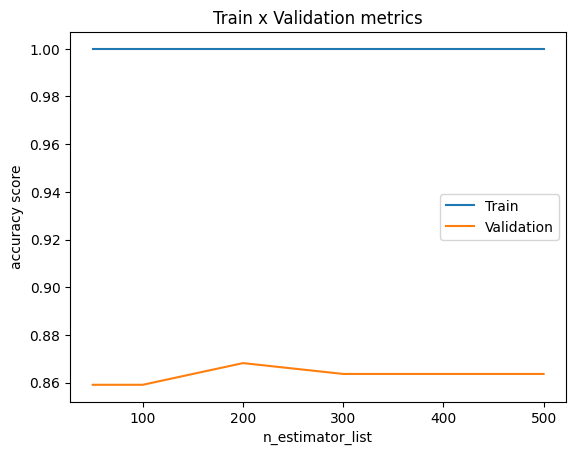

In [16]:
#plot graph
plt.plot(n_estimator_list,accuracy_train)
plt.plot(n_estimator_list,accuracy_val)
plt.ylabel('accuracy score')
plt.xlabel('n_estimator_list')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [17]:
#find optimal n estimator value in list
index=np.argmax(accuracy_val)
n_estimator=n_estimator_list[index]
n_estimator

200

In [18]:
#define list of accuracy and validation data
accuracy_train=[]
accuracy_val=[]

#list of all max depth
max_depth_list = [2, 3, 4, 5, 6, 8, 10]
#find optimum max_Depth which fit this model best
for max_depth in max_depth_list:

    #train model on train data
    model=XGBClassifier(n_estimators=n_estimator,max_depth=max_depth,random_state=1234).fit(x_train,y_train)

    #predict train and validation data
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)

    #find accuracy of train and validation data
    acc_train=accuracy_score(y_train,y_train_predict)
    acc_val=accuracy_score(y_val,y_val_predict)

    #add accuracy to list
    accuracy_train.append(acc_train)
    accuracy_val.append(acc_val)


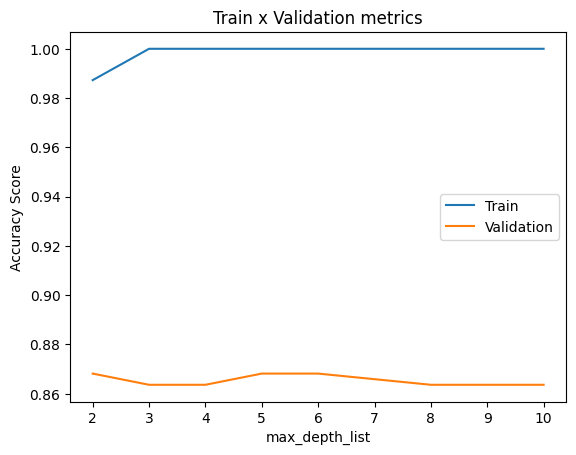

In [19]:
#plot graph
plt.plot(max_depth_list,accuracy_train)
plt.plot(max_depth_list,accuracy_val)
plt.ylabel('Accuracy Score')
plt.xlabel('max_depth_list')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [20]:
index=np.argmax(accuracy_val)
max_depth=max_depth_list[index]
max_depth

2

In [21]:
accuracy_train=[]
accuracy_val=[]

#list of learning rate 
learning_rate_list = [0.001,0.005,0.01,0.03, 0.05, 0.1, 0.2, 0.3]
for learning_rate in learning_rate_list:

    #train XGB model on train and validation data
    model=XGBClassifier(n_estimators=n_estimator,max_depth=max_depth,learning_rate=learning_rate,random_state=1234).fit(x_train,y_train)

    #predict train and validation data
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)

    #find accuracy of train and validation data
    acc_train=accuracy_score(y_train,y_train_predict)
    acc_val=accuracy_score(y_val,y_val_predict)

    #add to list
    accuracy_train.append(acc_train)
    accuracy_val.append(acc_val)


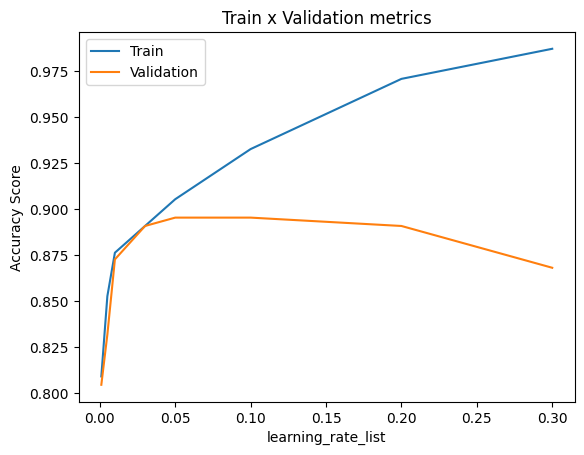

In [23]:
#plot graph
plt.plot(learning_rate_list,accuracy_train)
plt.plot(learning_rate_list,accuracy_val)
plt.ylabel('Accuracy Score')
plt.xlabel('learning_rate_list')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [24]:
#find optimum learning rate
index=np.argmax(accuracy_val)
learning_rate=learning_rate_list[index]
learning_rate

0.05

In [25]:
#trsain XGB model on all optimum hyper parameter
model=XGBClassifier(learning_rate=learning_rate,n_estimators=n_estimator,max_depth=max_depth,verbosity=1,random_state=55).fit(x_train,y_train)

#Save the trained model as a pickle file for future predictions
pickle.dump(model,open("heart_XGBClassifier.pkl","wb"))
